#Flagging Vendor Invoices for Manual Review

Objective: Predict whether a vendor invoice should be flagged for manual approval based on abnormal cost, freight, or delivery patterns, in order to reduce financial risk, improve operational efficiency, and prioritize human review where it adds the most value.

Manual invoice review is time-consuming and does not scale with transaction volume.

Abnormal freight charges, pricing deviations, or delivery delays often indicate errors, disputes, or compliance risks.

An automated flagging system enables finance teams to focus attention on high-risk invoices while allowing low-risk invoices to be processed automatically.

In [1]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 

In [2]:
conn=sqlite3.connect('/Users/Rohan/vendor invoice intelligence system/freight_cost_prediction/data/inventory (1).db')

In [3]:
purchase_agg_df=pd.read_sql_query("""
SELECT
    p.PONumber,
    COUNT(DISTINCT p.Brand) AS total_brands, 
    SUM(p.Quantity) AS total_item_quantity, 
    SUM(p.Dollars) AS total_item_dollars, 
    AVG(julianday(p.ReceivingDate) - julianday(p.PODate)) AS avg_receiving_delay
FROM purchases p
GROUP BY p.PONumber;
""", conn)

In [4]:
purchase_agg_df.shape

(5543, 5)

In [5]:
pd.read_sql_query("""
SELECT
    vi.Quantity AS invoice_quantity,
    vi.Dollars AS invoice_dollars,
    vi.Freight,
    
-- Days from PO Date to Invoice Date
    (julianday(vi.InvoiceDate) - julianday(vi.PODate)) AS days_po_to_invoice,

-- Days from Invoice Date to Pay Date
    (julianday(vi.PayDate) - julianday(vi.InvoiceDate)) AS days_to_pay

FROM vendor_invoice vi;
""", conn)



,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay
0,6,214.26,3.47,14.0,43.0
1,15,140.55,8.57,16.0,45.0
2,5,106.60,4.61,16.0,38.0
3,10100,137483.78,2935.20,23.0,24.0
4,1935,15527.25,429.20,14.0,36.0
...,...,...,...,...,...
5538,90,1563.00,8.60,16.0,35.0
5539,4617,37300.48,186.50,18.0,39.0
5540,9848,202815.78,932.95,11.0,33.0
5541,24747,149007.56,819.54,14.0,36.0


In [6]:
df=pd.read_sql_query("""
WITH purchase_agg AS (
    SELECT
        p.PONumber,
        COUNT(DISTINCT p.Brand) AS total_brands,
        SUM(p.Quantity) AS total_item_quantity,
        SUM(p.Dollars) AS total_item_dollars,
        AVG(julianday(p.ReceivingDate) - julianday(p.PODate)) AS avg_receiving_delay
    FROM purchases p
    GROUP BY p.PONumber
)

SELECT
    vi.PONumber,
    vi.Quantity AS invoice_quantity,
    vi.Dollars AS invoice_dollars,
    vi.Freight,
    (julianday(vi.InvoiceDate) - julianday(vi.PODate)) AS days_po_to_invoice,
    (julianday(vi.PayDate) - julianday(vi.InvoiceDate)) AS days_to_pay,
    pa.total_brands,
    pa.total_item_quantity,
    pa.total_item_dollars,
    pa.avg_receiving_delay
FROM vendor_invoice vi
LEFT JOIN purchase_agg pa
    ON vi.PONumber = pa.PONumber;
""", conn)

In [7]:
df


,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
0,8124,6,214.26,3.47,14.0,43.0,1,6,214.26,12.000000
1,8137,15,140.55,8.57,16.0,45.0,2,15,140.55,10.333333
2,8169,5,106.60,4.61,16.0,38.0,1,5,106.60,9.000000
3,8106,10100,137483.78,2935.20,23.0,24.0,81,10100,137483.78,12.614130
4,8170,1935,15527.25,429.20,14.0,36.0,29,1935,15527.25,8.752809
...,...,...,...,...,...,...,...,...,...,...
5538,13626,90,1563.00,8.60,16.0,35.0,2,223,6823.18,5.871795
5539,13661,4617,37300.48,186.50,18.0,39.0,110,24747,149007.56,5.050500
5540,13643,9848,202815.78,932.95,11.0,33.0,5,180,2559.72,5.000000
5541,13602,24747,149007.56,819.54,14.0,36.0,83,43240,318075.65,8.045541


In [8]:
df.isnull().sum()

PONumber               0
invoice_quantity       0
invoice_dollars        0
Freight                0
days_po_to_invoice     0
days_to_pay            0
total_brands           0
total_item_quantity    0
total_item_dollars     0
avg_receiving_delay    0
dtype: int64

In [9]:
df.dtypes

PONumber                 int64
invoice_quantity         int64
invoice_dollars        float64
Freight                float64
days_po_to_invoice     float64
days_to_pay            float64
total_brands             int64
total_item_quantity      int64
total_item_dollars     float64
avg_receiving_delay    float64
dtype: object

In [10]:
def create_invoice_risk_label(row):

    # Invoice total mismatch with item-level total
    if abs(row["invoice_dollars"] - row["total_item_dollars"]) > 5:
        return 1

    # Abnormally high receiving delay
    if row["avg_receiving_delay"] > 10:
        return 1

    return 0

df["flag_invoice"] = df.apply(create_invoice_risk_label, axis=1)
df["flag_invoice"].value_counts()

flag_invoice
0    3693
1    1850
Name: count, dtype: int64

<Axes: xlabel='flag_invoice'>

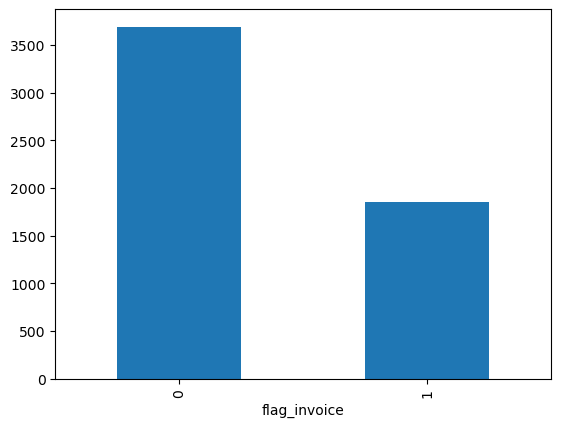

In [11]:
df["flag_invoice"].value_counts().plot(kind='bar')

In [12]:
df.corr()

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay,flag_invoice
PONumber,1.000000,0.049230,0.058917,0.043617,-0.002234,0.012558,0.013423,0.049442,0.059221,-0.042362,0.564946
invoice_quantity,0.049230,1.000000,0.963831,0.946550,0.000526,0.022284,0.566394,0.706117,0.668171,0.000519,0.032783
invoice_dollars,0.058917,0.963831,1.000000,0.985141,0.001610,0.025661,0.536952,0.667666,0.679537,0.004694,0.037994
Freight,0.043617,0.946550,0.985141,1.000000,0.003265,0.025513,0.536381,0.656616,0.670768,0.015645,0.037759
days_po_to_invoice,-0.002234,0.000526,0.001610,0.003265,1.000000,-0.370432,0.009519,0.005543,0.007931,0.515538,0.183115
days_to_pay,0.012558,0.022284,0.025661,0.025513,-0.370432,1.000000,0.020336,0.016203,0.015610,-0.029403,-0.005289
total_brands,0.013423,0.566394,0.536952,0.536381,0.009519,0.020336,1.000000,0.783825,0.753092,0.000496,0.008961
total_item_quantity,0.049442,0.706117,0.667666,0.656616,0.005543,0.016203,0.783825,1.000000,0.963831,-0.014016,0.032783
total_item_dollars,0.059221,0.668171,0.679537,0.670768,0.007931,0.015610,0.753092,0.963831,1.000000,-0.014251,0.037994
avg_receiving_delay,-0.042362,0.000519,0.004694,0.015645,0.515538,-0.029403,0.000496,-0.014016,-0.014251,1.000000,0.311667


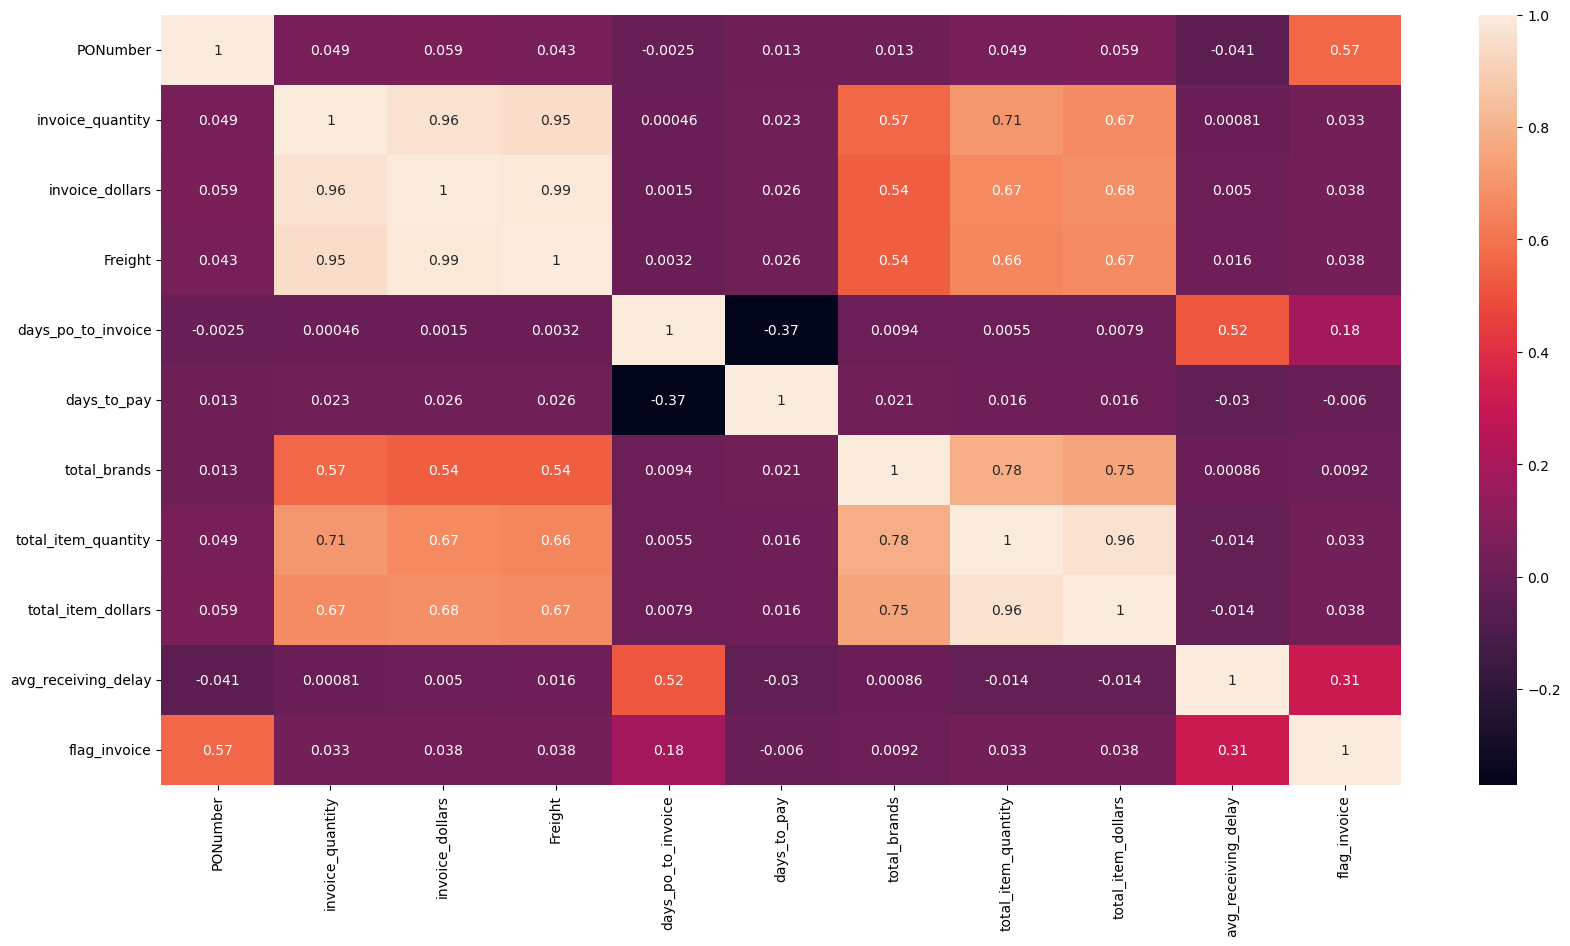

In [13]:
plt.figure(figsize=(20,10))
sns.heatmap(df.iloc[:1:-1].corr(),annot =True)
plt.show()

In [14]:
flagged=df[df['flag_invoice']==1]
normal=df[df['flag_invoice']==0]

In [15]:
significant_features=[]
non_significant_features=[]
results=[]

In [16]:
metrics = ['invoice_quantity', 'invoice_dollars', 'Freight',
'days_po_to_invoice', 'days_to_pay', 'total_brands',
'total_item_quantity', 'total_item_dollars',
'avg_receiving_delay']

In [17]:
from scipy.stats import ttest_ind

for metric in metrics:
    flagged_mean = flagged[metric].mean()
    normal_mean = normal[metric].mean()

    # t-test
    t_stat, p_value = ttest_ind(
        flagged[metric].dropna(),
        normal[metric].dropna(),
        equal_var=False
    )

    if p_value < 0.05:
        significant_features.append(metric)
        results.append({
            "metric": metric,
            "flagged_mean": round(flagged_mean, 2),
            "normal_mean": round(normal_mean, 2),
            "p_value": round(p_value, 3)
        })
    else:
        non_significant_features.append(metric)

        print(metric)
        print({
            "metric": metric,
            "flagged_mean": round(flagged_mean, 2),
            "normal_mean": round(normal_mean, 2),
            "p_value": round(p_value, 3)
        })

days_to_pay
{'metric': 'days_to_pay', 'flagged_mean': np.float64(35.42), 'normal_mean': np.float64(35.49), 'p_value': np.float64(0.692)}
total_brands
{'metric': 'total_brands', 'flagged_mean': np.float64(42.29), 'normal_mean': np.float64(40.82), 'p_value': np.float64(0.508)}


In [18]:
non_significant_features

['days_to_pay', 'total_brands']

In [19]:
significant_features

['invoice_quantity',
 'invoice_dollars',
 'Freight',
 'days_po_to_invoice',
 'total_item_quantity',
 'total_item_dollars',
 'avg_receiving_delay']

In [20]:
results

[{'metric': 'invoice_quantity',
  'flagged_mean': np.float64(6728.28),
  'normal_mean': np.float64(5723.55),
  'p_value': np.float64(0.021)},
 {'metric': 'invoice_dollars',
  'flagged_mean': np.float64(65600.61),
  'normal_mean': np.float64(54302.64),
  'p_value': np.float64(0.008)},
 {'metric': 'Freight',
  'flagged_mean': np.float64(334.02),
  'normal_mean': np.float64(276.89),
  'p_value': np.float64(0.008)},
 {'metric': 'days_po_to_invoice',
  'flagged_mean': np.float64(17.23),
  'normal_mean': np.float64(16.02),
  'p_value': np.float64(0.0)},
 {'metric': 'total_item_quantity',
  'flagged_mean': np.float64(6728.28),
  'normal_mean': np.float64(5723.55),
  'p_value': np.float64(0.021)},
 {'metric': 'total_item_dollars',
  'flagged_mean': np.float64(65600.61),
  'normal_mean': np.float64(54302.64),
  'p_value': np.float64(0.008)},
 {'metric': 'avg_receiving_delay',
  'flagged_mean': np.float64(8.47),
  'normal_mean': np.float64(7.27),
  'p_value': np.float64(0.0)}]

In [21]:
X = df [['invoice_quantity', 'invoice_dollars', 'Freight', 'total_brands', 'total_item_quantity', 'days_po_to_invoice', 'total_item_dollars']]
y = df ['flag_invoice']

In [23]:


# Required imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model 1: Logistic Regression
model1 = LogisticRegression(random_state=42)
model1.fit(X_train_scaled, y_train)

# Model 2: Decision Tree
model2 = DecisionTreeClassifier(random_state=42)
model2.fit(X_train_scaled, y_train)

# Model 3: Random Forest
model3 = RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled, y_train)

print("All models trained successfully.")

All models trained successfully.


In [24]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# =========================
# Logistic Regression Evaluation
# =========================
y_pred1 = model1.predict(X_test_scaled)

print("Logistic Regression Performance:")
print("Accuracy :", round(accuracy_score(y_test, y_pred1), 2))
print("Classification Report :")
print(classification_report(y_test, y_pred1))

print("Confusion Matrix :")
print(confusion_matrix(y_test, y_pred1))


# =========================
# Decision Tree Evaluation
# =========================
y_pred2 = model2.predict(X_test_scaled)

print("\nDecision Tree Classifier Performance:")
print("Accuracy :", round(accuracy_score(y_test, y_pred2), 2))
print("Classification Report :")
print(classification_report(y_test, y_pred2))

print("Confusion Matrix :")
print(confusion_matrix(y_test, y_pred2))


# =========================
# Random Forest Evaluation
# =========================
y_pred3 = model3.predict(X_test_scaled)

print("\nRandom Forest Classifier Performance:")
print("Accuracy :", round(accuracy_score(y_test, y_pred3), 2))
print("Classification Report :")
print(classification_report(y_test, y_pred3))

print("Confusion Matrix :")
print(confusion_matrix(y_test, y_pred3))

Logistic Regression Performance:
Accuracy : 0.66
Classification Report :
              precision    recall  f1-score   support

           0       0.66      0.98      0.79       725
           1       0.58      0.06      0.10       384

    accuracy                           0.66      1109
   macro avg       0.62      0.52      0.45      1109
weighted avg       0.63      0.66      0.55      1109

Confusion Matrix :
[[709  16]
 [362  22]]

Decision Tree Classifier Performance:
Accuracy : 0.81
Classification Report :
              precision    recall  f1-score   support

           0       0.85      0.87      0.86       725
           1       0.74      0.71      0.73       384

    accuracy                           0.81      1109
   macro avg       0.80      0.79      0.79      1109
weighted avg       0.81      0.81      0.81      1109

Confusion Matrix :
[[630  95]
 [111 273]]

Random Forest Classifier Performance:
Accuracy : 0.87
Classification Report :
              precision    reca

In [25]:
model3.feature_importances_

array([0.15137936, 0.15124851, 0.14480642, 0.07920458, 0.17669413,
       0.07717963, 0.21948736])

In [26]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model3.feature_importances_
}).sort_values(by="importance", ascending=False)

(feature_importance)


,feature,importance
6,total_item_dollars,0.219487
4,total_item_quantity,0.176694
0,invoice_quantity,0.151379
1,invoice_dollars,0.151249
2,Freight,0.144806
3,total_brands,0.079205
5,days_po_to_invoice,0.077180


In [27]:
X = df [['invoice_quantity', 'invoice_dollars', 'Freight',  'total_item_quantity', 'total_item_dollars']]
y = df ['flag_invoice']

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Random Forest Model
model3 = RandomForestClassifier(random_state=42)

# Train the model
model3.fit(X_train_scaled, y_train)

# Random Forest Evaluation
# =========================
y_pred3 = model3.predict(X_test_scaled)

print("\nRandom Forest Classifier Performance:")
print("Accuracy :", round(accuracy_score(y_test, y_pred3), 2))
print("Classification Report :")
print(classification_report(y_test, y_pred3))

print("Confusion Matrix :")
print(confusion_matrix(y_test, y_pred3))


Random Forest Classifier Performance:
Accuracy : 0.88
Classification Report :
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       725
           1       0.94      0.72      0.81       384

    accuracy                           0.88      1109
   macro avg       0.90      0.84      0.86      1109
weighted avg       0.89      0.88      0.88      1109

Confusion Matrix :
[[706  19]
 [109 275]]


In [29]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 4, 5, 6],
    "min_samples_split": [2, 3, 5],
    "min_samples_leaf": [1, 2, 5],
    "criterion": ["gini", "entropy"]
}

In [31]:
from sklearn.metrics import (
    make_scorer,
    f1_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Function to evaluate model
def evaluate_model(model, X_test, y_test, model_name):

    # Predictions
    y_pred = model.predict(X_test)

    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)

    # F1 Score
    f1 = f1_score(y_test, y_pred)

    print(f"\n{model_name} Results")
    print("-" * 40)

    print("Accuracy:", accuracy)
    print("F1 Score:", f1)

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))


# Random Forest Model
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

# Hyperparameter Grid
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 4, 5, 6],
    "min_samples_split": [2, 3, 5],
    "min_samples_leaf": [1, 2, 5],
    "criterion": ["gini", "entropy"]
}

# Scoring Metric
scorer = make_scorer(f1_score)

# Grid Search
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring=scorer,
    cv=5,
    verbose=2,
    n_jobs=-1
)

# Train Model
grid_search.fit(X_train_scaled, y_train)

# Best Parameters
print("Best Parameters:", grid_search.best_params_)

# Evaluate Best Model
evaluate_model(
    grid_search.best_estimator_,
    X_test_scaled,
    y_test,
    'Random Forest Classifier'
)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Parameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}

Random Forest Classifier Results
----------------------------------------
Accuracy: 0.8881875563570785
F1 Score: 0.8143712574850299

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.98      0.92       725
           1       0.96      0.71      0.81       384

    accuracy                           0.89      1109
   macro avg       0.91      0.85      0.87      1109
weighted avg       0.90      0.89      0.88      1109


Confusion Matrix:
[[713  12]
 [112 272]]


In [32]:


from sklearn.metrics import confusion_matrix

In [34]:
confusion_matrix(grid_search.predict(X_test_scaled),y_test)

array([[713, 112],
       [ 12, 272]])

In [36]:
confusion_matrix(model3.predict(X_test_scaled),y_test)

array([[706, 109],
       [ 19, 275]])

In [37]:
grid_search.best_params_

{'criterion': 'gini',
 'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 5,
 'n_estimators': 100}